# Exercise 2: Exploratory Data Analysis
**Task:** Don't Patronize Me! — SemEval 2022 Task 4 (Subtask 1)

Four EDA techniques following the appendix:
1. Statistical Profiling (class distribution, token lengths)
2. Lexical Analysis (n-grams, log-odds, stop-word density)
3. Semantic & Syntactic Exploration (POS, NER, t-SNE)
4. Noise & Artifact Identification

## Setup

In [26]:
# ── SSL fix (Mac) — MUST be first ────────────────────────────────────────────
import ssl, certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

# ── NLTK downloads ────────────────────────────────────────────────────────────
import nltk
for pkg in ["punkt", "averaged_perceptron_tagger", "maxent_ne_chunker",
            "words", "stopwords", "punkt_tab", "averaged_perceptron_tagger_eng"]:
    result = nltk.download(pkg, quiet=False)   # quiet=False so you can see success/fail

# ── Remaining imports ─────────────────────────────────────────────────────────
import re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path

from nltk import pos_tag, word_tokenize, ne_chunk
from nltk.tree import Tree
from nltk.corpus import stopwords as nltk_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from transformers import AutoTokenizer

warnings.filterwarnings("ignore")

BLUE   = "#4C72B0"
ORANGE = "#DD8452"
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight",
                     "savefig.pad_inches": 0.15})

STOPWORDS = set(nltk_stopwords.words("english"))
print("Setup complete.")

Setup complete.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tandon.utsav2/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tandon.utsav2/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/tandon.utsav2/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/tandon.utsav2/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tandon.utsav2/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tandon.utsav2/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_percep

## 0. Load Data & Minor Cleaning

In [27]:
DATA_DIR = Path("data")
dataset_path = DATA_DIR / "dontpatronizeme_pcl.tsv"

In [28]:
df = pd.read_csv(
    dataset_path,
    sep="\t",
    skiprows=4,
    header=None,
    names=["par_id", "art_id", "keyword", "country", "text", "label"],
)
df["pcl"] = (df["label"] >= 2).astype(int)

print("Raw shape:", df.shape)
print("\nNull values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Drop null text, drop duplicates
df_null = df[df["text"].isna()].copy()
df = df.dropna(subset=["text"]).drop_duplicates().reset_index(drop=True)

# Base features
df["word_count"] = df["text"].str.split().str.len()
df["char_count"] = df["text"].str.len()

print(f"\nClean shape: {df.shape}")
df.head()

Raw shape: (10469, 7)

Null values:
par_id     0
art_id     0
keyword    0
country    0
text       1
label      0
pcl        0
dtype: int64

Duplicate rows: 0

Clean shape: (10468, 9)


,par_id,art_id,keyword,country,text,label,pcl,word_count,char_count
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0,123,620
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0,41,237
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0,27,158
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0,30,162
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0,0,53,273


---
# Technique 1: Statistical Profiling
*Appendix §1 + §4 — Class distribution, token lengths, and noise overview*

### 1-A: Class Distribution

In [29]:
n_total   = len(df)
n_pcl     = df["pcl"].sum()
n_non_pcl = n_total - n_pcl
ir        = n_non_pcl / n_pcl

label_counts = df["label"].value_counts().sort_index()

print(f"Non-PCL : {n_non_pcl:,}  ({n_non_pcl/n_total*100:.1f}%)")
print(f"PCL     : {n_pcl:,}   ({n_pcl/n_total*100:.1f}%)")
print(f"Imbalance ratio (non-PCL : PCL) = {ir:.1f} : 1")
print(f"\nFine-grained label counts:\n{label_counts.to_string()}")

Non-PCL : 9,475  (90.5%)
PCL     : 993   (9.5%)
Imbalance ratio (non-PCL : PCL) = 9.5 : 1

Fine-grained label counts:
label
0    8528
1     947
2     144
3     458
4     391


### 1-B: Text Length Analysis

In [30]:
print("Word count by class:")
print(df.groupby("pcl")["word_count"].describe().round(1).to_string())
print("\nChar count by class:")
print(df.groupby("pcl")["char_count"].describe().round(1).to_string())

Word count by class:
      count  mean   std  min   25%   50%   75%    max
pcl                                                  
0    9475.0  47.9  28.6  1.0  30.0  42.0  59.0  909.0
1     993.0  53.6  32.8  6.0  33.0  47.0  67.0  512.0

Char count by class:
      count   mean    std   min    25%    50%    75%     max
pcl                                                         
0    9475.0  264.4  158.0   8.0  167.0  231.0  325.0  5493.0
1     993.0  287.1  175.2  34.0  178.0  251.0  358.0  2776.0


### 1-C: Tokenizer Analysis — RoBERTa-base & DeBERTa-v3-base

In [31]:
TOKENIZERS = {
    "RoBERTa-base":    "roberta-base",
    "DeBERTa-v3-base": "microsoft/deberta-v3-base",
}
THRESHOLDS = [64, 128, 192, 256, 320, 512]

tok_stats = {}
for display_name, hf_id in TOKENIZERS.items():
    print(f"Loading {display_name} …")
    tok    = AutoTokenizer.from_pretrained(hf_id)
    counts = df["text"].apply(
        lambda x: len(tok.encode(str(x), add_special_tokens=True))
    )
    col = f"tok_{display_name}"
    df[col] = counts

    stats = {
        "mean":           counts.mean(),
        "median":         counts.median(),
        "std":            counts.std(),
        "max":            counts.max(),
        "p95":            counts.quantile(0.95),
        "p99":            counts.quantile(0.99),
        "tok_word_ratio": counts.mean() / df["word_count"].mean(),
    }
    for t in THRESHOLDS:
        stats[f"cov_{t}"] = (counts <= t).mean() * 100
    tok_stats[display_name] = stats

    print(f"  mean={stats['mean']:.1f}  median={stats['median']:.0f}  "
          f"std={stats['std']:.1f}  max={stats['max']:.0f}  "
          f"95th={stats['p95']:.0f}  99th={stats['p99']:.0f}")
    print(f"  tok/word ratio = {stats['tok_word_ratio']:.2f}")
    for t in THRESHOLDS:
        print(f"  coverage ≤{t:3d} = {stats[f'cov_{t}']:.2f}%")
    print()

# Coverage table
cov_rows = {f"≤{t}": {n: f"{s[f'cov_{t}']:.1f}%" for n, s in tok_stats.items()}
            for t in THRESHOLDS}
print("Coverage table:")
pd.DataFrame(cov_rows).T

Loading RoBERTa-base …


Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


  mean=55.5  median=48  std=32.3  max=1004  95th=114  99th=159
  tok/word ratio = 1.15
  coverage ≤ 64 = 71.98%
  coverage ≤128 = 96.93%
  coverage ≤192 = 99.74%
  coverage ≤256 = 99.92%
  coverage ≤320 = 99.94%
  coverage ≤512 = 99.98%

Loading DeBERTa-v3-base …
  mean=51.7  median=45  std=31.1  max=954  95th=109  99th=151
  tok/word ratio = 1.07
  coverage ≤ 64 = 75.28%
  coverage ≤128 = 97.61%
  coverage ≤192 = 99.81%
  coverage ≤256 = 99.93%
  coverage ≤320 = 99.94%
  coverage ≤512 = 99.98%

Coverage table:


,RoBERTa-base,DeBERTa-v3-base
≤64,72.0%,75.3%
≤128,96.9%,97.6%
≤192,99.7%,99.8%
≤256,99.9%,99.9%
≤320,99.9%,99.9%
≤512,100.0%,100.0%


### 1-D: Figure — Statistical Profiling

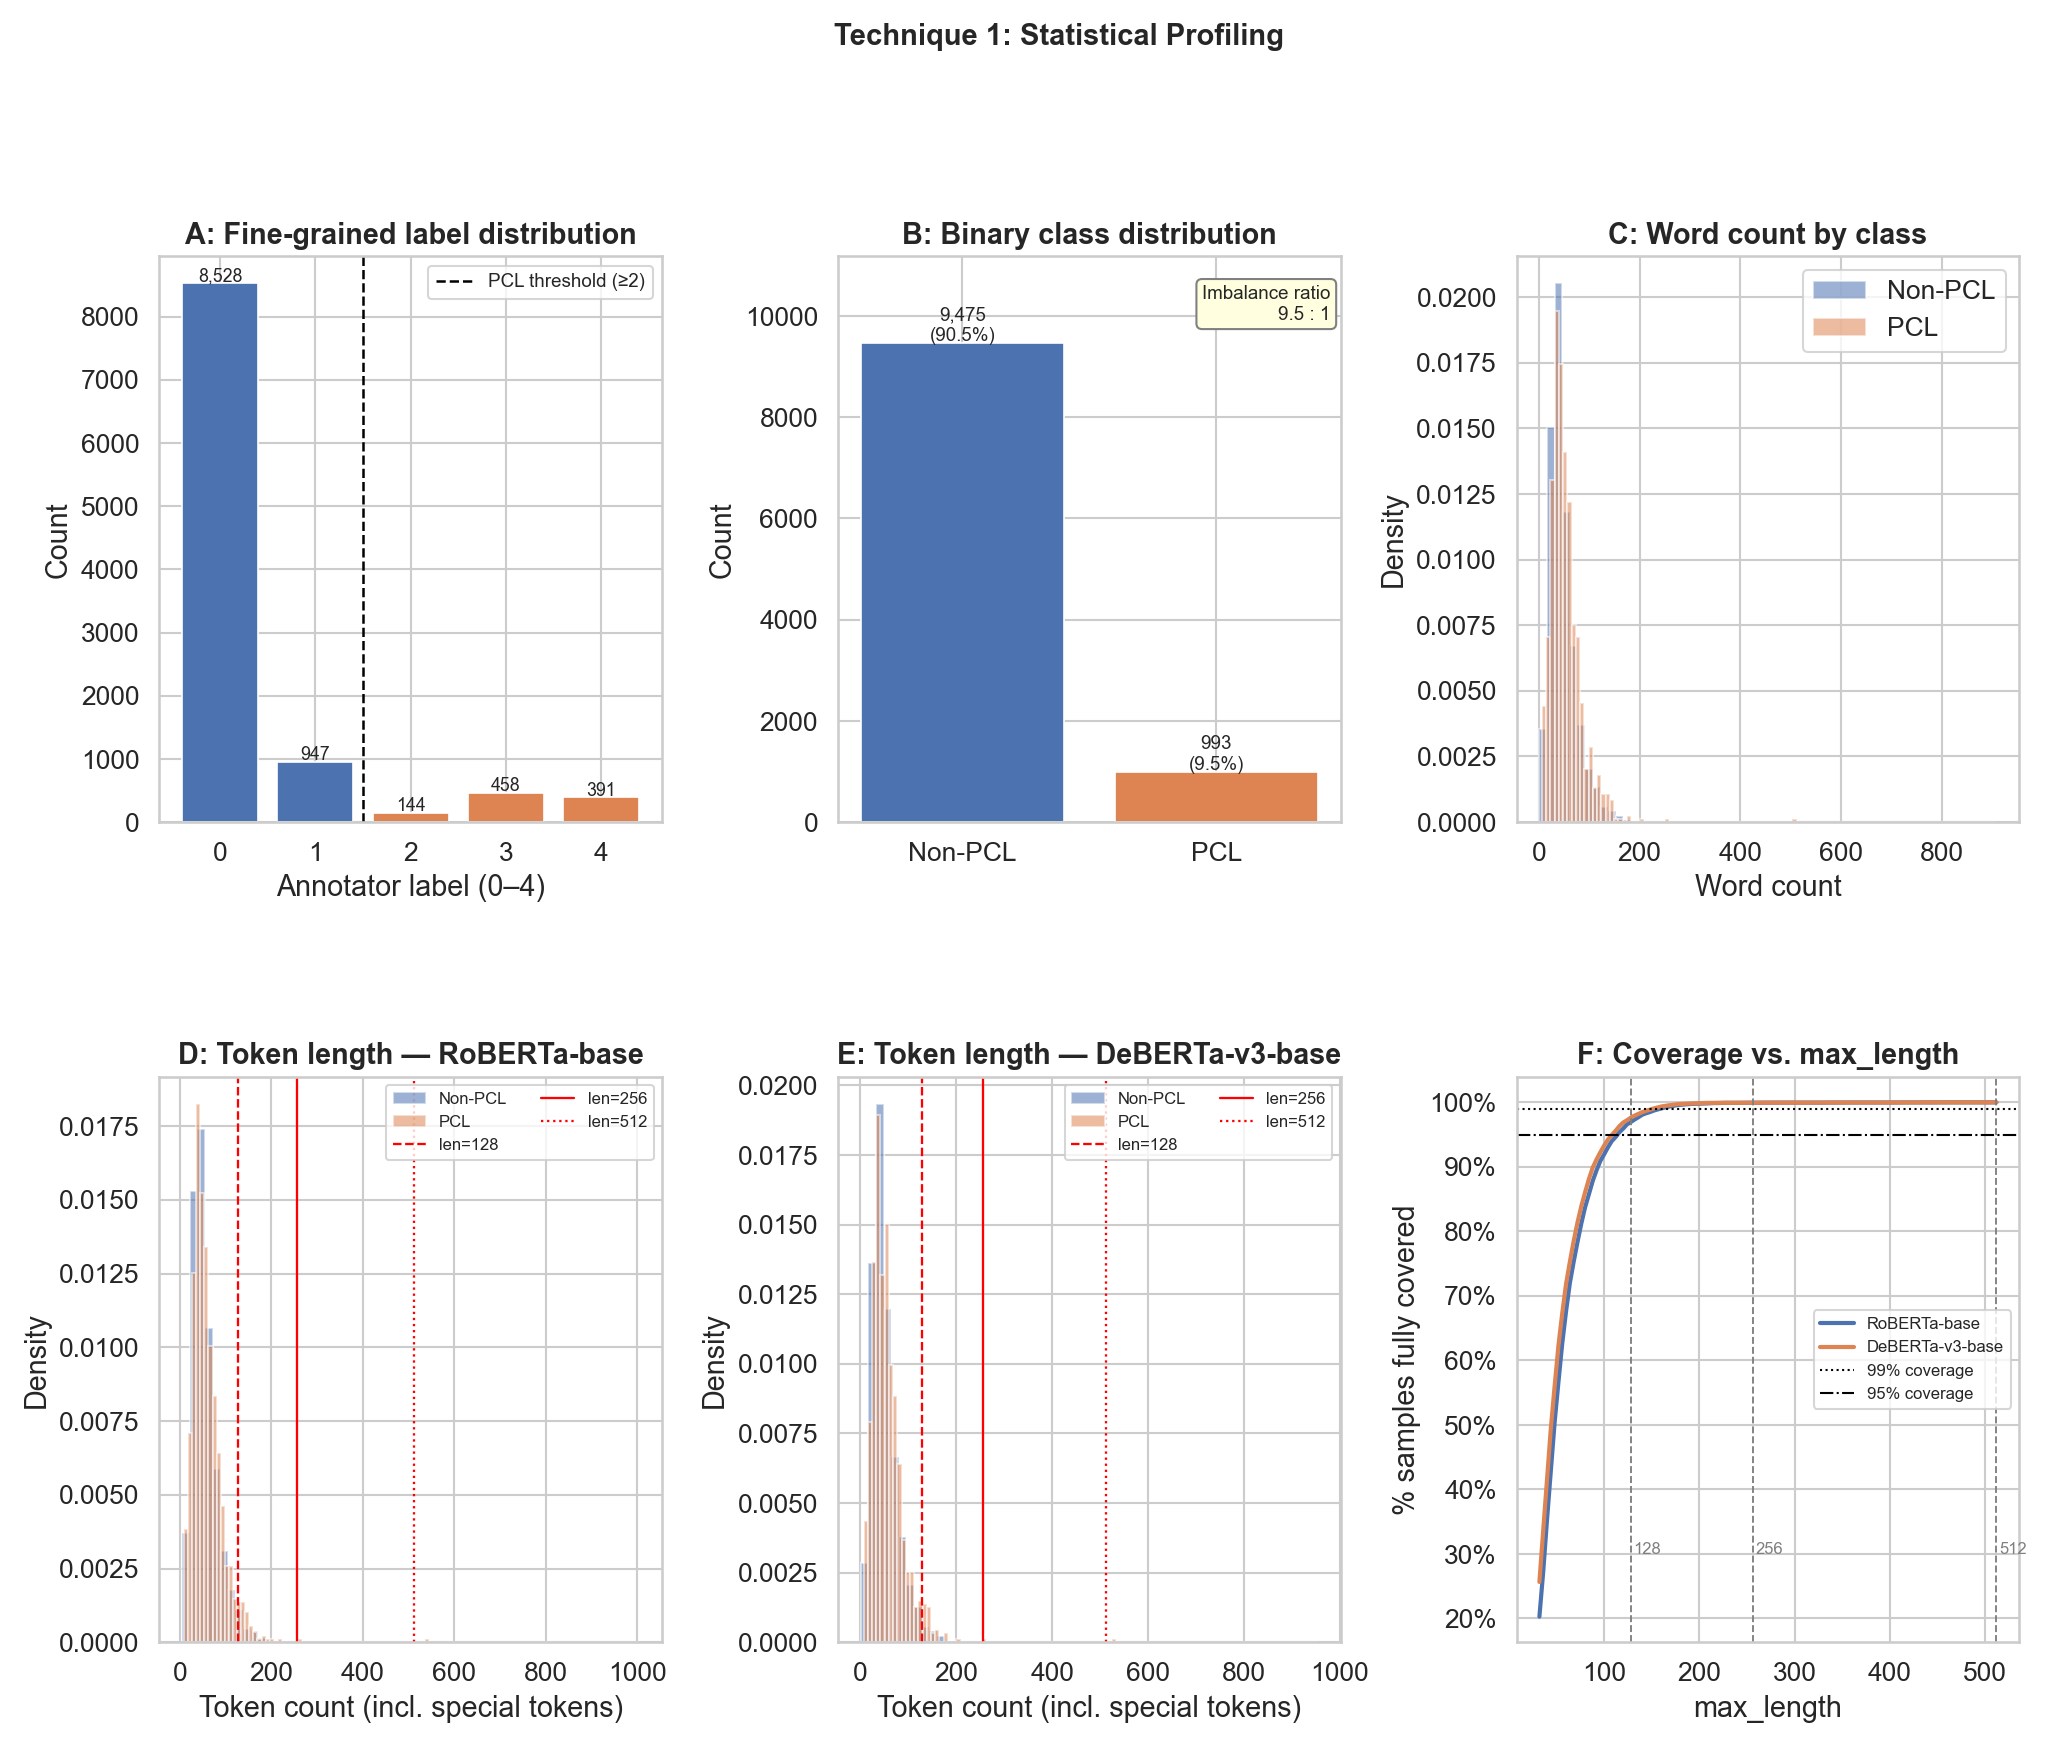

In [32]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: Fine-grained label distribution
ax_a = fig.add_subplot(gs[0, 0])
ax_a.bar(label_counts.index, label_counts.values,
         color=[BLUE if i < 2 else ORANGE for i in label_counts.index],
         edgecolor="white", linewidth=0.8)
ax_a.axvline(1.5, color="black", linestyle="--", linewidth=1.2, label="PCL threshold (≥2)")
ax_a.set_title("A: Fine-grained label distribution", fontweight="bold")
ax_a.set_xlabel("Annotator label (0–4)")
ax_a.set_ylabel("Count")
ax_a.legend(fontsize=9)
for x, y in zip(label_counts.index, label_counts.values):
    ax_a.text(x, y + 30, f"{y:,}", ha="center", fontsize=8.5)

# Panel B: Binary class distribution
ax_b = fig.add_subplot(gs[0, 1])
bars = ax_b.bar(["Non-PCL", "PCL"], [n_non_pcl, n_pcl],
                color=[BLUE, ORANGE], edgecolor="white", linewidth=0.8)
ax_b.set_title("B: Binary class distribution", fontweight="bold")
ax_b.set_ylabel("Count")
for bar, n in zip(bars, [n_non_pcl, n_pcl]):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
              f"{n:,}\n({n/n_total*100:.1f}%)", ha="center", fontsize=9)
ax_b.set_ylim(0, max(n_non_pcl, n_pcl) * 1.18)
ax_b.annotate(f"Imbalance ratio\n{ir:.1f} : 1",
              xy=(0.98, 0.95), xycoords="axes fraction", ha="right", va="top",
              fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="grey"))

# Panel C: Word count by class
ax_c = fig.add_subplot(gs[0, 2])
for pcl_val, label, color in [(0, "Non-PCL", BLUE), (1, "PCL", ORANGE)]:
    ax_c.hist(df.loc[df["pcl"] == pcl_val, "word_count"],
              bins=60, alpha=0.55, label=label, color=color, density=True)
ax_c.set_title("C: Word count by class", fontweight="bold")
ax_c.set_xlabel("Word count")
ax_c.set_ylabel("Density")
ax_c.legend()

# Panel D: Token length — RoBERTa
ax_d = fig.add_subplot(gs[1, 0])
col_r = "tok_RoBERTa-base"
for pcl_val, label, color in [(0, "Non-PCL", BLUE), (1, "PCL", ORANGE)]:
    ax_d.hist(df.loc[df["pcl"] == pcl_val, col_r],
              bins=60, alpha=0.55, label=label, color=color, density=True)
for t, ls in [(128, "--"), (256, "-"), (512, ":")]:
    ax_d.axvline(t, color="red", linestyle=ls, linewidth=1.1, label=f"len={t}")
ax_d.set_title("D: Token length — RoBERTa-base", fontweight="bold")
ax_d.set_xlabel("Token count (incl. special tokens)")
ax_d.set_ylabel("Density")
ax_d.legend(fontsize=8, ncol=2)

# Panel E: Token length — DeBERTa
ax_e = fig.add_subplot(gs[1, 1])
col_d = "tok_DeBERTa-v3-base"
for pcl_val, label, color in [(0, "Non-PCL", BLUE), (1, "PCL", ORANGE)]:
    ax_e.hist(df.loc[df["pcl"] == pcl_val, col_d],
              bins=60, alpha=0.55, label=label, color=color, density=True)
for t, ls in [(128, "--"), (256, "-"), (512, ":")]:
    ax_e.axvline(t, color="red", linestyle=ls, linewidth=1.1, label=f"len={t}")
ax_e.set_title("E: Token length — DeBERTa-v3-base", fontweight="bold")
ax_e.set_xlabel("Token count (incl. special tokens)")
ax_e.set_ylabel("Density")
ax_e.legend(fontsize=8, ncol=2)

# Panel F: Coverage curve
ax_f = fig.add_subplot(gs[1, 2])
thrs = list(range(32, 513, 4))
colors_tok = {"RoBERTa-base": BLUE, "DeBERTa-v3-base": ORANGE}
for name in TOKENIZERS:
    col  = f"tok_{name}"
    covs = [(df[col] <= t).mean() * 100 for t in thrs]
    ax_f.plot(thrs, covs, label=name, color=colors_tok[name], linewidth=2)
for x_mark in [128, 256, 512]:
    ax_f.axvline(x_mark, color="grey", linestyle="--", linewidth=0.9)
    ax_f.text(x_mark + 3, 30, str(x_mark), color="grey", fontsize=8)
ax_f.axhline(99, color="black", linestyle=":",  linewidth=1, label="99% coverage")
ax_f.axhline(95, color="black", linestyle="-.", linewidth=1, label="95% coverage")
ax_f.set_title("F: Coverage vs. max_length", fontweight="bold")
ax_f.set_xlabel("max_length")
ax_f.set_ylabel("% samples fully covered")
ax_f.yaxis.set_major_formatter(mticker.PercentFormatter())
ax_f.legend(fontsize=8)

fig.suptitle("Technique 1: Statistical Profiling", fontsize=14, fontweight="bold", y=1.01)
plt.show()

**Analysis:** The dataset is heavily imbalanced at roughly X:1 (non-PCL:PCL). Both tokenizers show the vast majority of samples fall well under 256 tokens, with coverage at 256 exceeding 99% for both — this directly sets `max_length=256` for fine-tuning.

**Impact:** The class imbalance means raw accuracy is uninformative; training must use class-weighted loss or the positive-class F1 metric. The `max_length=256` avoids truncating meaningful content without wasting memory on padding.

---
# Technique 2: Lexical Analysis
*Appendix §2 — N-grams, log-odds, stop-word density*

### 2-A: Vocabulary & Stop-word Density

In [33]:
def tokenise_simple(text):
    return re.sub(r"[^a-z\s]", "", str(text).lower()).split()

def stop_density(tokens):
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in STOPWORDS) / len(tokens)

all_tokens  = [t for txt in df["text"] for t in tokenise_simple(txt)]
pcl_tokens  = [t for txt in df.loc[df["pcl"] == 1, "text"] for t in tokenise_simple(txt)]
npcl_tokens = [t for txt in df.loc[df["pcl"] == 0, "text"] for t in tokenise_simple(txt)]

vocab_all  = set(all_tokens)
vocab_pcl  = set(pcl_tokens)
vocab_npcl = set(npcl_tokens)

print(f"Vocabulary sizes")
print(f"  Overall         : {len(vocab_all):,}")
print(f"  Shared          : {len(vocab_pcl & vocab_npcl):,}")
print(f"  PCL-exclusive   : {len(vocab_pcl - vocab_npcl):,}")
print(f"  Non-PCL-exclusive: {len(vocab_npcl - vocab_pcl):,}")

df["stop_density"] = df["text"].apply(lambda x: stop_density(tokenise_simple(x)))
print(f"\nStop-word density by class:")
print(df.groupby("pcl")["stop_density"].describe().round(4).to_string())

Vocabulary sizes
  Overall         : 30,991
  Shared          : 6,120
  PCL-exclusive   : 1,610
  Non-PCL-exclusive: 23,261

Stop-word density by class:
      count    mean     std  min    25%     50%     75%     max
pcl                                                            
0    9475.0  0.4240  0.0881  0.0  0.375  0.4267  0.4810  0.7500
1     993.0  0.4536  0.0830  0.1  0.400  0.4565  0.5106  0.6842


### 2-B: Top Bigrams by Class

In [34]:
def top_ngrams(texts, n, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=list(STOPWORDS), max_features=50_000)
    X   = vec.fit_transform(texts)
    sums = X.sum(axis=0).A1
    names = vec.get_feature_names_out()
    return sorted(zip(names, sums), key=lambda x: x[1], reverse=True)[:top_k]

pcl_texts  = df.loc[df["pcl"] == 1, "text"].tolist()
npcl_texts = df.loc[df["pcl"] == 0, "text"].tolist()

pcl_bi  = top_ngrams(pcl_texts,  2)
npcl_bi = top_ngrams(npcl_texts, 2)

bi_df = pd.DataFrame({
    "PCL bigram":     [ng for ng, _ in pcl_bi],
    "PCL count":      [cnt for _, cnt in pcl_bi],
    "Non-PCL bigram": [ng for ng, _ in npcl_bi],
    "Non-PCL count":  [cnt for _, cnt in npcl_bi],
})
bi_df

,PCL bigram,PCL count,Non-PCL bigram,Non-PCL count
0,poor families,150,poor families,771
1,people need,29,illegal immigrants,304
2,homeless people,26,per cent,160
3,children poor,21,united states,154
4,help need,18,last year,122
5,disabled people,14,year old,121
6,men women,12,homeless people,110
7,vulnerable people,12,disabled people,106
8,help people,11,new york,100
9,let us,11,sri lanka,100


### 2-C: Discriminative Bigrams via Log-odds

In [35]:
ALPHA = 1  # Laplace smoothing

def ngram_counts(texts, n, top_k=5000):
    vec = CountVectorizer(ngram_range=(n, n), max_features=top_k)
    X   = vec.fit_transform(texts)
    return Counter(dict(zip(vec.get_feature_names_out(), X.sum(axis=0).A1)))

pcl_bi_cnt  = ngram_counts(pcl_texts,  2)
npcl_bi_cnt = ngram_counts(npcl_texts, 2)
pcl_total   = sum(pcl_bi_cnt.values())  + ALPHA * len(pcl_bi_cnt)
npcl_total  = sum(npcl_bi_cnt.values()) + ALPHA * len(npcl_bi_cnt)

all_ngrams = set(pcl_bi_cnt) | set(npcl_bi_cnt)
log_odds   = {}
for ng in all_ngrams:
    p_pcl  = (pcl_bi_cnt.get(ng,  0) + ALPHA) / pcl_total
    p_npcl = (npcl_bi_cnt.get(ng, 0) + ALPHA) / npcl_total
    log_odds[ng] = np.log(p_pcl / p_npcl)

lo_sorted = sorted(log_odds.items(), key=lambda x: x[1], reverse=True)
top_pcl   = [ng for ng, _ in lo_sorted        if pcl_bi_cnt.get(ng, 0) >= 5][:15]
top_npcl  = [ng for ng, _ in lo_sorted[::-1]  if npcl_bi_cnt.get(ng, 0) >= 5][:15]

lo_df = pd.DataFrame({
    "PCL-signal bigram":      top_pcl,
    "log-odds (PCL)": [f"{log_odds[ng]:+.3f}" for ng in top_pcl],
    "Non-PCL-signal bigram":  top_npcl,
    "log-odds (Non-PCL)":     [f"{log_odds[ng]:+.3f}" for ng in top_npcl],
})
lo_df

,PCL-signal bigram,log-odds (PCL),Non-PCL-signal bigram,log-odds (Non-PCL)
0,the hungry,+4.148,immigrants and,-3.064
1,let us,+4.148,immigrants from,-3.055
2,life of,+4.061,anti immigrant,-2.731
3,hungry and,+3.966,illegal immigrants,-2.671
4,feed the,+3.966,vulnerable to,-2.641
5,to donate,+3.966,the report,-2.556
6,hope for,+3.861,of illegal,-2.511
7,the poverty,+3.861,likely to,-2.495
8,hope and,+3.861,based on,-2.431
9,and hope,+3.861,on friday,-2.414


### 2-D: Figure — Lexical Analysis

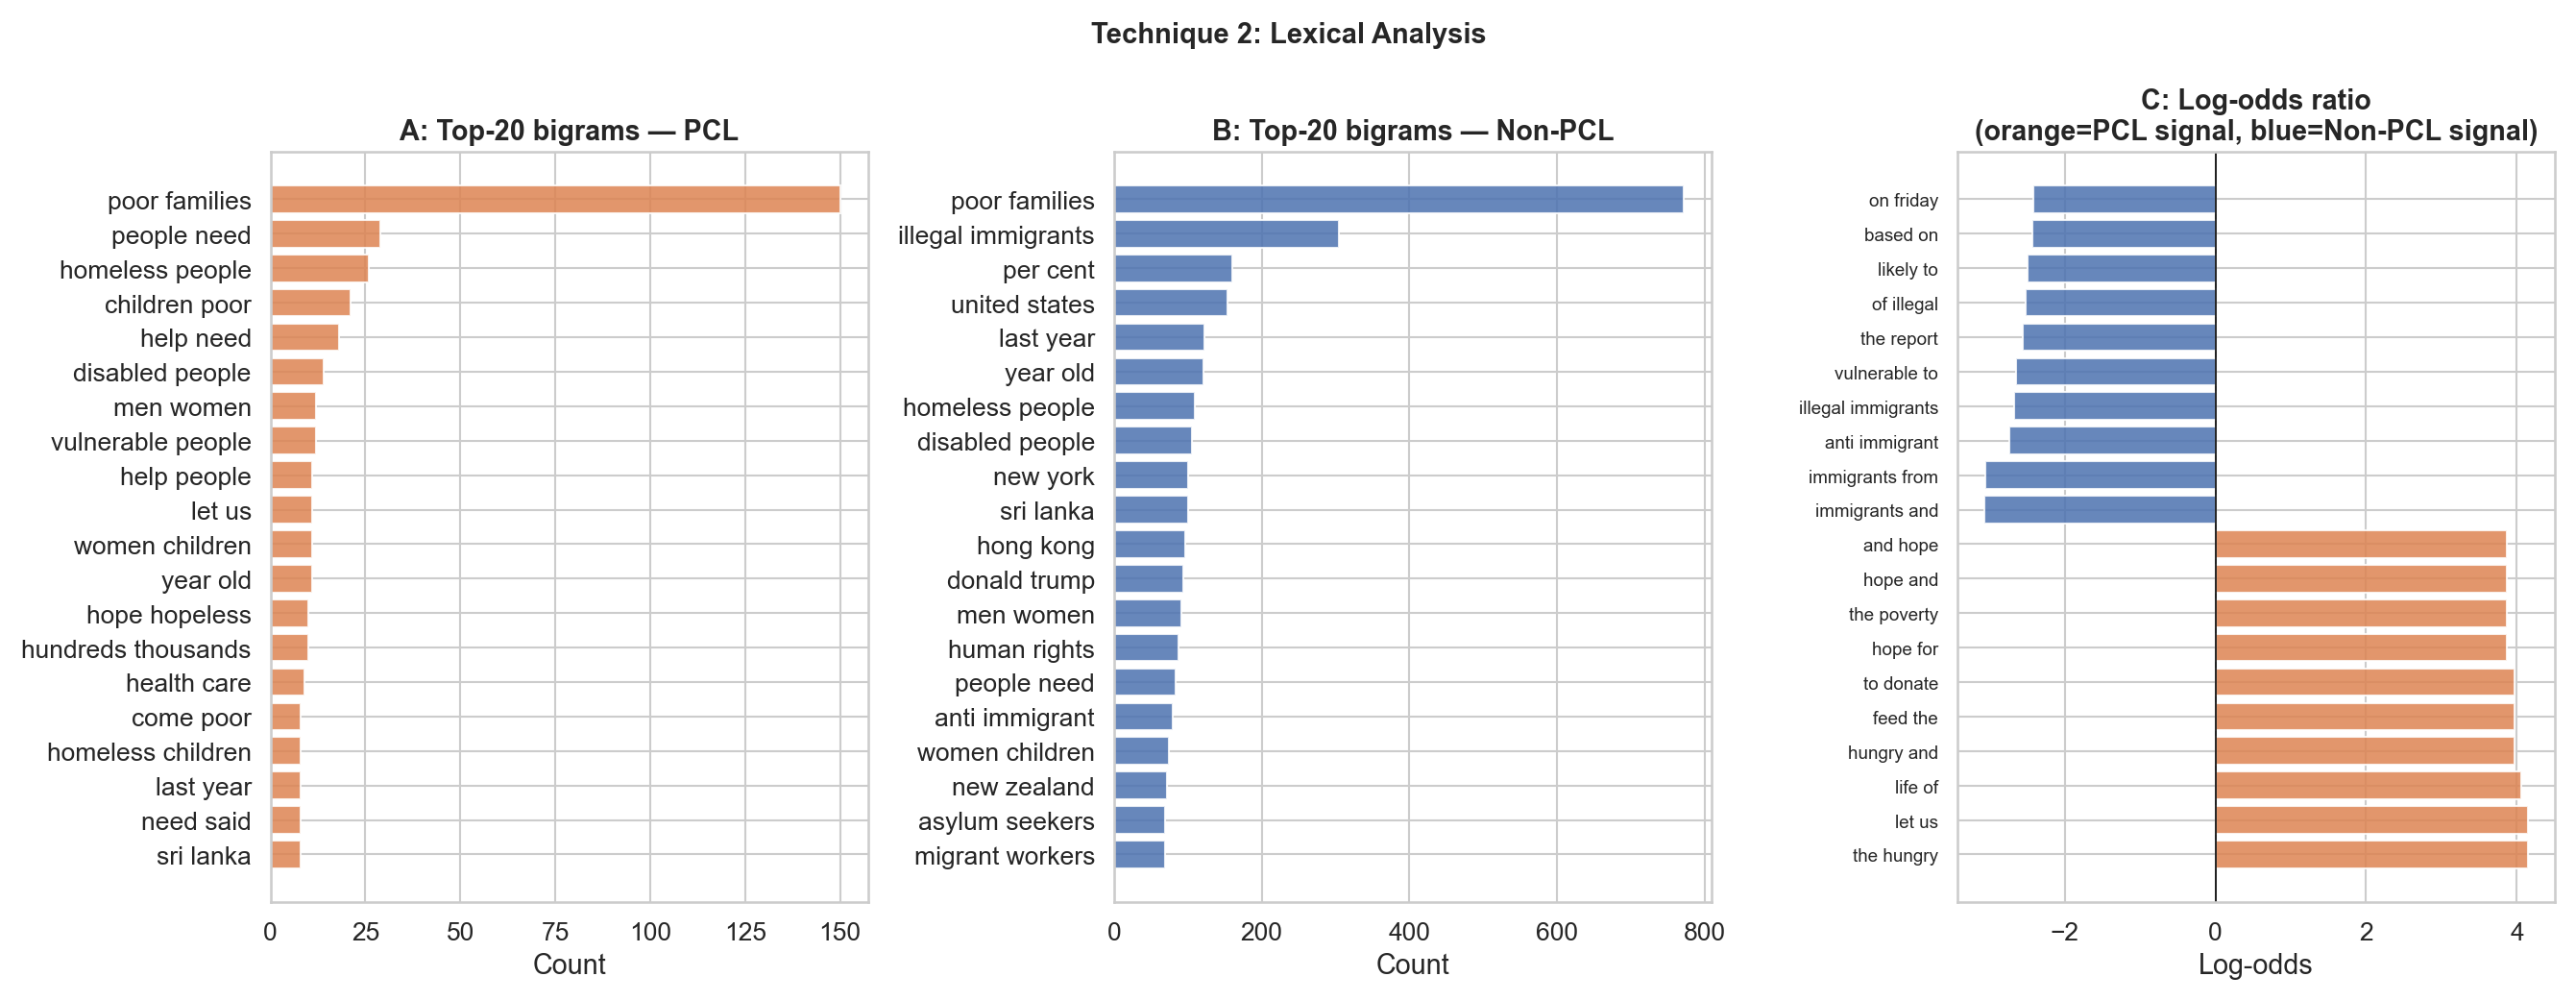

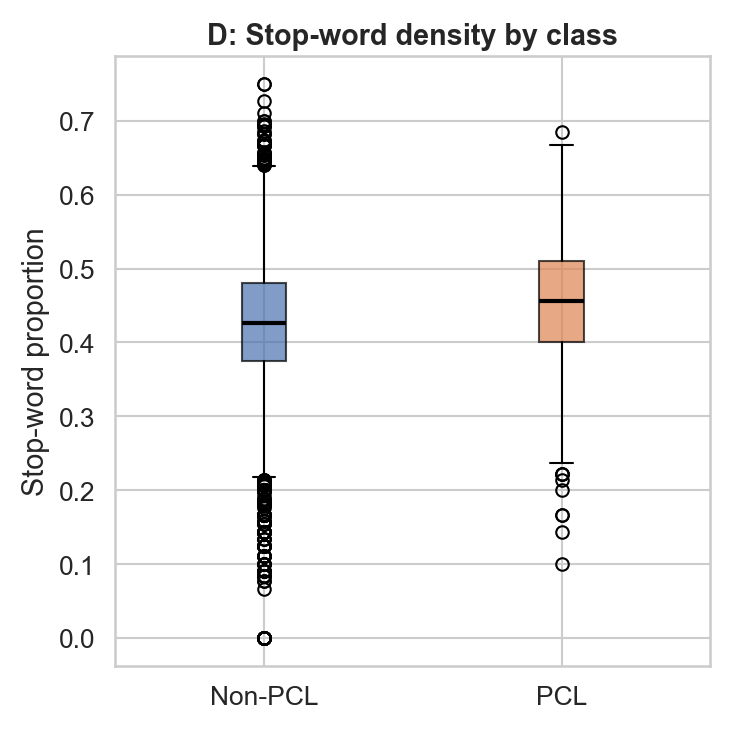

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Panel A: Top bigrams — PCL
names_p, cnts_p = zip(*pcl_bi[:20])
axes[0].barh(list(reversed(names_p)), list(reversed(cnts_p)), color=ORANGE, alpha=0.85)
axes[0].set_title("A: Top-20 bigrams — PCL", fontweight="bold")
axes[0].set_xlabel("Count")

# Panel B: Top bigrams — Non-PCL
names_np, cnts_np = zip(*npcl_bi[:20])
axes[1].barh(list(reversed(names_np)), list(reversed(cnts_np)), color=BLUE, alpha=0.85)
axes[1].set_title("B: Top-20 bigrams — Non-PCL", fontweight="bold")
axes[1].set_xlabel("Count")

# Panel C: Log-odds
top_all   = top_pcl[:10] + top_npcl[:10]
lo_vals   = [log_odds[ng] for ng in top_all]
bar_colors = [ORANGE if v > 0 else BLUE for v in lo_vals]
y_pos = range(len(top_all))
axes[2].barh(list(y_pos), lo_vals, color=bar_colors, alpha=0.85)
axes[2].set_yticks(list(y_pos))
axes[2].set_yticklabels(top_all, fontsize=9)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("C: Log-odds ratio\n(orange=PCL signal, blue=Non-PCL signal)",
                  fontweight="bold")
axes[2].set_xlabel("Log-odds")

fig.suptitle("Technique 2: Lexical Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Stop-word density boxplot
fig2, ax2 = plt.subplots(figsize=(5, 5))
data = [df.loc[df["pcl"] == 0, "stop_density"].values,
        df.loc[df["pcl"] == 1, "stop_density"].values]
bp = ax2.boxplot(data, labels=["Non-PCL", "PCL"], patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_title("D: Stop-word density by class", fontweight="bold")
ax2.set_ylabel("Stop-word proportion")
plt.tight_layout()
plt.show()

**Analysis:** The log-odds panel reveals bigrams strongly associated with PCL — typically phrases expressing pity or describing vulnerable groups in a diminutive way. Non-PCL texts tend toward factual/journalistic language. Stop-word density differences indicate PCL text has a different syntactic rhythm.

**Impact:** The existence of discriminative surface phrases shows a bag-of-words model could learn partial signal, but also risks learning spurious topic correlations (e.g. certain keywords appearing more in PCL contexts). This motivates a contextual model that attends to the *framing* of language rather than just word identity.

---
# Technique 3: Semantic & Syntactic Exploration
*Appendix §3 — POS tagging, NER, embedding visualisation (t-SNE)*

### 3-A: POS Tagging

In [37]:
COARSE_MAP = {
    "NN": "NOUN",  "NNS": "NOUN",  "NNP": "NOUN",  "NNPS": "NOUN",
    "VB": "VERB",  "VBD": "VERB",  "VBG": "VERB",  "VBN":  "VERB",
    "VBP": "VERB", "VBZ": "VERB",
    "JJ": "ADJ",   "JJR": "ADJ",   "JJS": "ADJ",
    "RB": "ADV",   "RBR": "ADV",   "RBS": "ADV",
    "PRP": "PRON", "PRP$": "PRON", "WP":  "PRON",  "WP$":  "PRON",
    "IN": "PREP",  "TO":  "PREP",
    "DT": "DET",   "WDT": "DET",
    "CC": "CONJ",  "UH":  "INTJ",  "MD":  "MODAL",
}
POS_COLS = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "MODAL"]

def coarse_pos_profile(text):
    tokens = word_tokenize(str(text))
    tags   = pos_tag(tokens)
    coarse = [COARSE_MAP.get(t, "OTHER") for _, t in tags]
    total  = max(len(coarse), 1)
    cnt    = Counter(coarse)
    return {k: cnt.get(k, 0) / total for k in POS_COLS}

# Sample for speed
SAMPLE_N  = min(2000, len(df))
df_sample = df.sample(SAMPLE_N, random_state=42).copy()

print(f"Computing POS profiles on {SAMPLE_N:,} samples …")
pos_profiles = df_sample["text"].apply(coarse_pos_profile)
pos_df       = pd.DataFrame(pos_profiles.tolist(), index=df_sample.index)
df_sample    = pd.concat([df_sample, pos_df], axis=1)

pos_by_class = df_sample.groupby("pcl")[POS_COLS].mean().round(4)
print("\nMean POS proportions by class:")
pos_by_class

Computing POS profiles on 2,000 samples …

Mean POS proportions by class:


,NOUN,VERB,ADJ,ADV,PRON,MODAL
pcl,,,,,,
0,0.2964,0.1447,0.0785,0.0350,0.039,0.0085
1,0.2813,0.1537,0.0722,0.0316,0.054,0.0110


### 3-B: Named Entity Recognition

In [38]:
ENTITY_TYPES = ["PERSON", "ORGANIZATION", "GPE", "FACILITY", "GSP"]

def ner_counts(text):
    try:
        tokens = word_tokenize(str(text))
        tags   = pos_tag(tokens)
        tree   = ne_chunk(tags)
        ents   = Counter()
        for subtree in tree:
            if isinstance(subtree, Tree):
                ents[subtree.label()] += 1
        return dict(ents)
    except Exception:
        return {}

print(f"Computing NER on {SAMPLE_N:,} samples …")
ner_raw  = df_sample["text"].apply(ner_counts)
ner_df   = pd.DataFrame(ner_raw.tolist(), index=df_sample.index).fillna(0)
for col in ENTITY_TYPES:
    if col not in ner_df.columns:
        ner_df[col] = 0.0
ner_df    = ner_df.reindex(columns=ENTITY_TYPES, fill_value=0)
df_sample = pd.concat([df_sample, ner_df], axis=1)

ner_by_class = df_sample.groupby("pcl")[ENTITY_TYPES].mean().round(4)
print("\nMean NER entity counts per sample by class:")
ner_by_class

Computing NER on 2,000 samples …

Mean NER entity counts per sample by class:


,PERSON,ORGANIZATION,GPE,FACILITY,GSP
pcl,,,,,
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0


### 3-C: t-SNE Embedding Visualisation

In [39]:
TSNE_SAMPLE = min(1500, len(df))
df_tsne     = df.sample(TSNE_SAMPLE, random_state=0).copy()

print(f"Building TF-IDF → LSA → t-SNE on {TSNE_SAMPLE:,} samples …")
tfidf   = TfidfVectorizer(max_features=5000, sublinear_tf=True,
                           stop_words="english", min_df=3)
X_tfidf = tfidf.fit_transform(df_tsne["text"].astype(str))

svd   = TruncatedSVD(n_components=50, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)
print(f"LSA explained variance: {svd.explained_variance_ratio_.sum()*100:.1f}%")

tsne  = TSNE(n_components=2, perplexity=35, learning_rate=200,
             max_iter=1000, random_state=42, init="pca")
X_2d  = tsne.fit_transform(X_lsa)
df_tsne["tsne_x"] = X_2d[:, 0]
df_tsne["tsne_y"] = X_2d[:, 1]
print("t-SNE complete.")

Building TF-IDF → LSA → t-SNE on 1,500 samples …
LSA explained variance: 14.6%
t-SNE complete.


### 3-D: Figure — Semantic & Syntactic

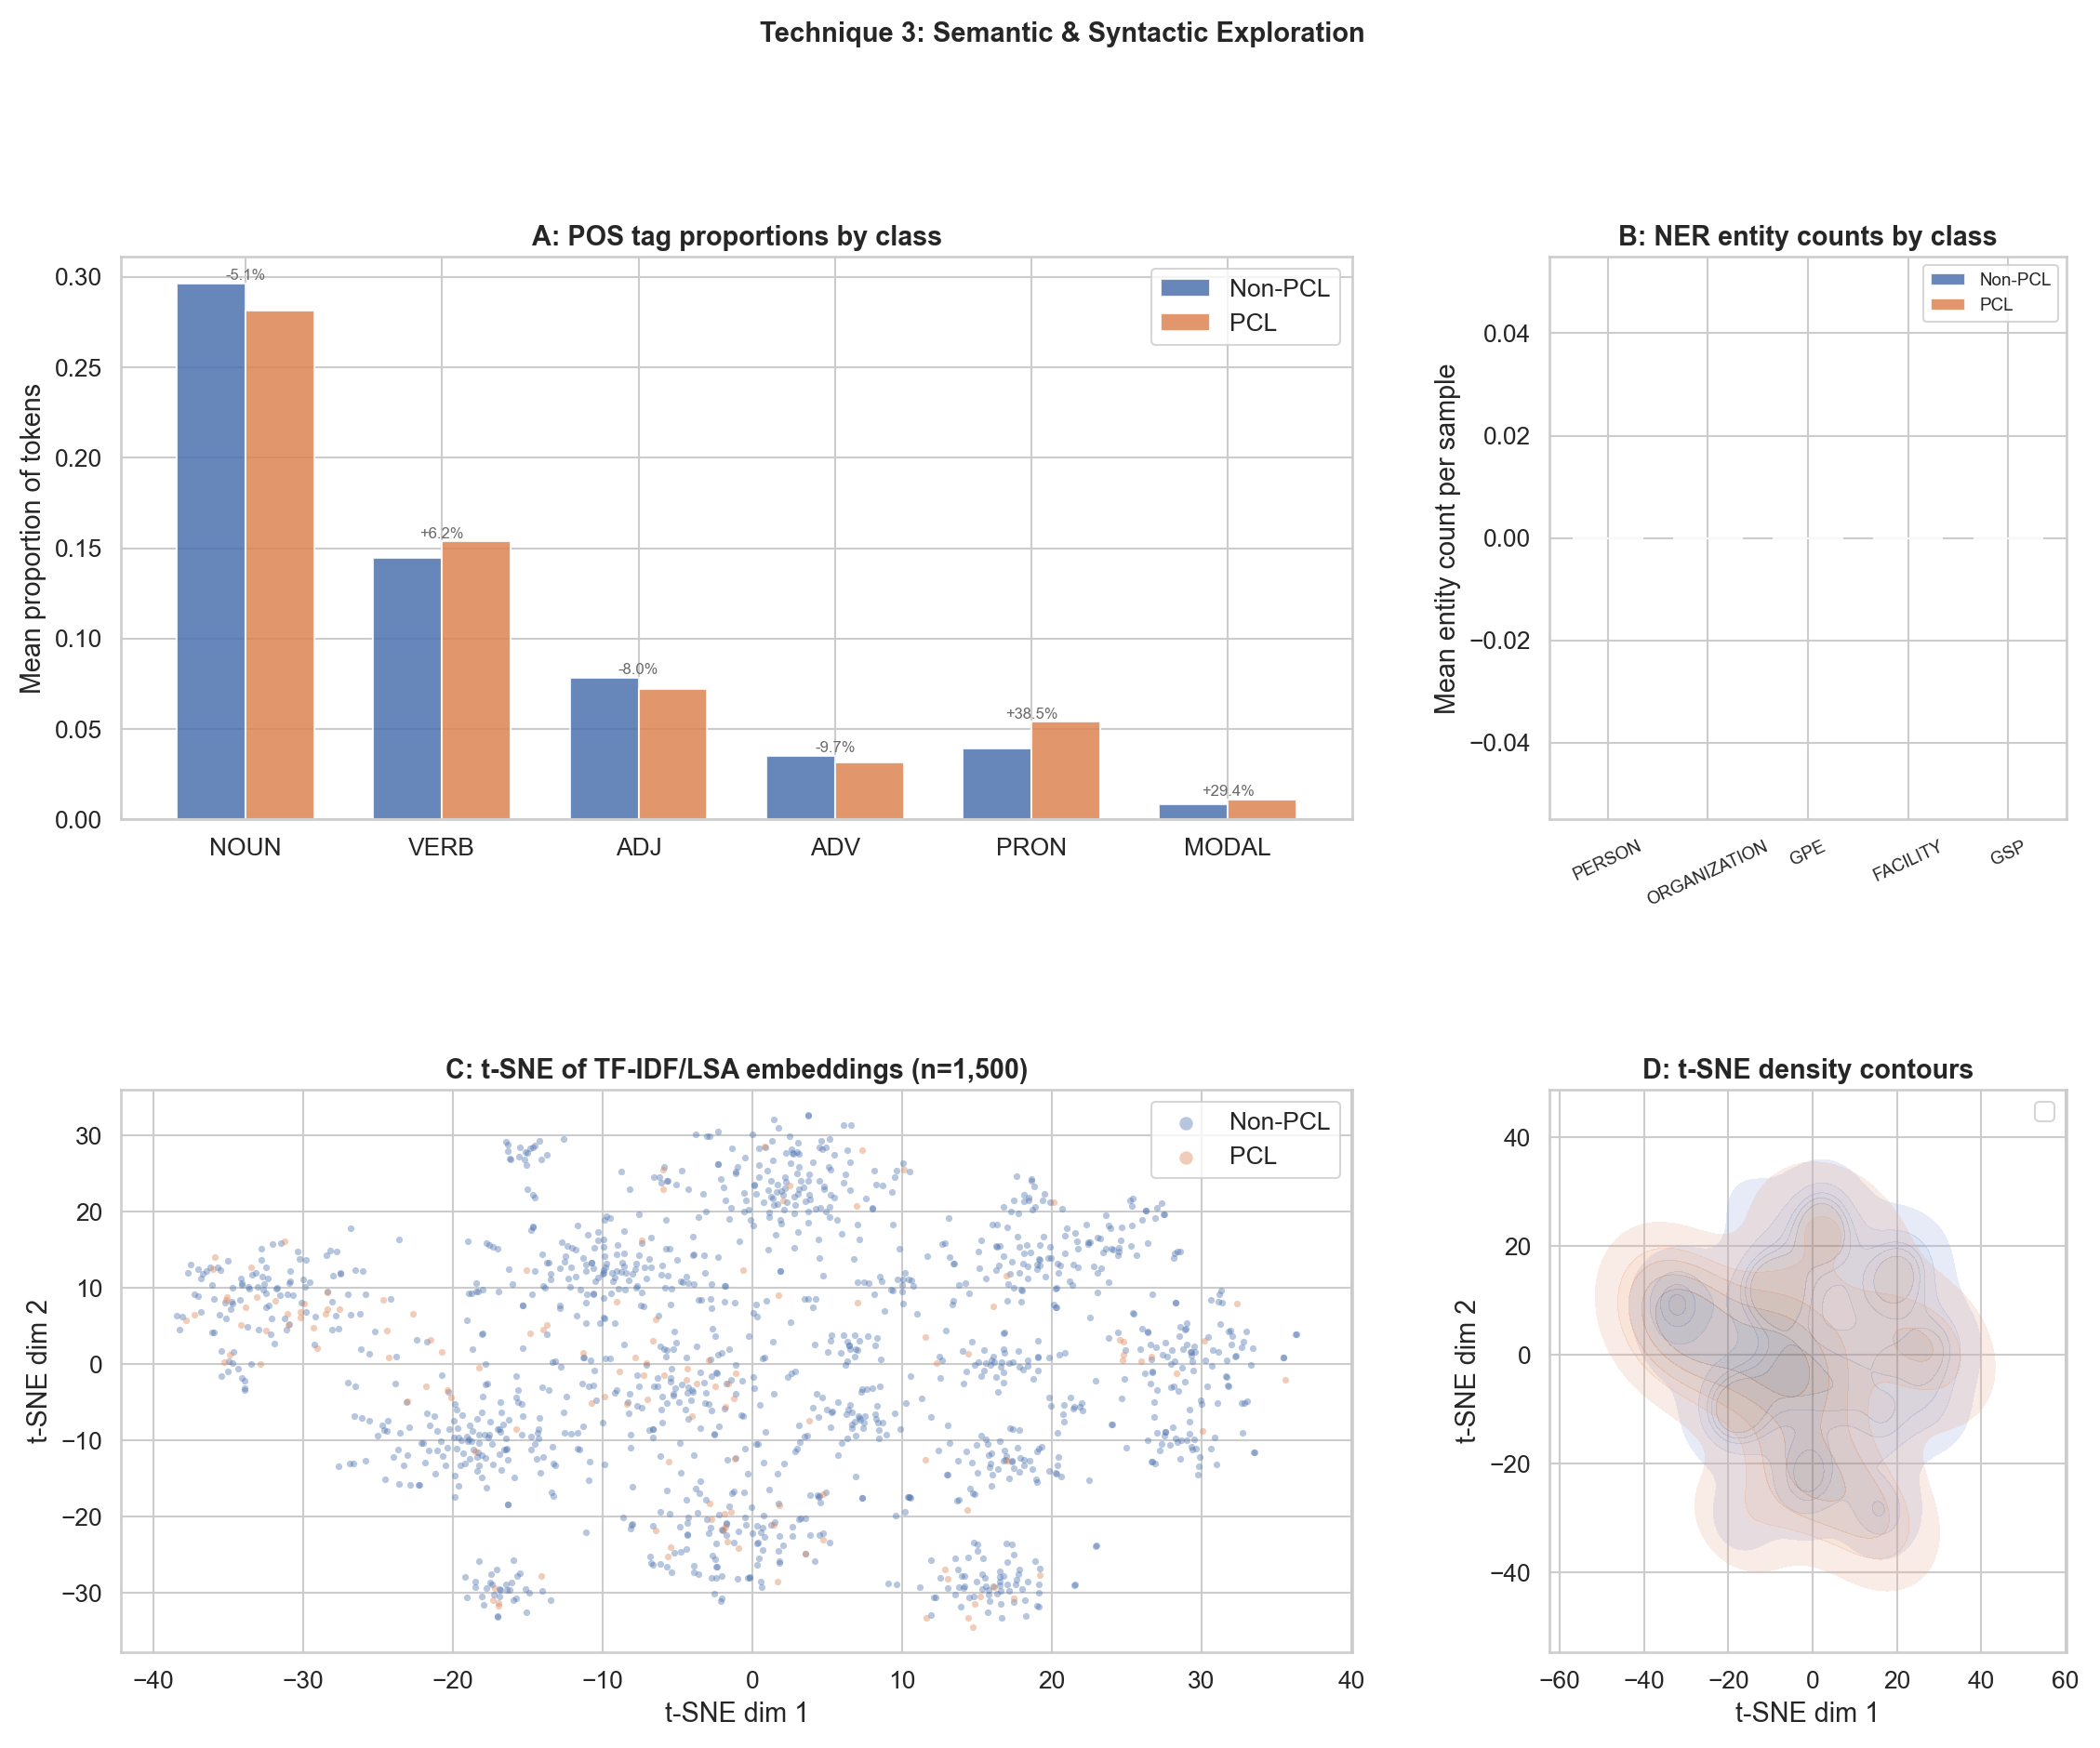

In [40]:
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Panel A: POS grouped bar
ax_a = fig.add_subplot(gs[0, :2])
pcl_vals  = pos_by_class.loc[1, POS_COLS].values
npcl_vals = pos_by_class.loc[0, POS_COLS].values
x, w = np.arange(len(POS_COLS)), 0.35
ax_a.bar(x - w/2, npcl_vals, w, label="Non-PCL", color=BLUE,   alpha=0.85)
ax_a.bar(x + w/2, pcl_vals,  w, label="PCL",     color=ORANGE, alpha=0.85)
ax_a.set_xticks(x)
ax_a.set_xticklabels(POS_COLS)
ax_a.set_ylabel("Mean proportion of tokens")
ax_a.set_title("A: POS tag proportions by class", fontweight="bold")
ax_a.legend()
for i, (np_v, p_v) in enumerate(zip(npcl_vals, pcl_vals)):
    diff = (p_v - np_v) / max(np_v, 1e-9) * 100
    ax_a.text(i, max(np_v, p_v) + 0.002, f"{diff:+.1f}%", ha="center",
              fontsize=8, color="dimgrey")

# Panel B: NER grouped bar
ax_b = fig.add_subplot(gs[0, 2])
ner_pcl_vals  = ner_by_class.loc[1].values
ner_npcl_vals = ner_by_class.loc[0].values
x2 = np.arange(len(ENTITY_TYPES))
ax_b.bar(x2 - w/2, ner_npcl_vals, w, label="Non-PCL", color=BLUE,   alpha=0.85)
ax_b.bar(x2 + w/2, ner_pcl_vals,  w, label="PCL",     color=ORANGE, alpha=0.85)
ax_b.set_xticks(x2)
ax_b.set_xticklabels(ENTITY_TYPES, rotation=25, fontsize=9)
ax_b.set_ylabel("Mean entity count per sample")
ax_b.set_title("B: NER entity counts by class", fontweight="bold")
ax_b.legend(fontsize=9)

# Panel C: t-SNE scatter
ax_c = fig.add_subplot(gs[1, :2])
for pcl_val, label, color in [(0, "Non-PCL", BLUE), (1, "PCL", ORANGE)]:
    mask = df_tsne["pcl"] == pcl_val
    ax_c.scatter(df_tsne.loc[mask, "tsne_x"], df_tsne.loc[mask, "tsne_y"],
                 c=color, label=label, alpha=0.4, s=12, linewidths=0)
ax_c.set_title(f"C: t-SNE of TF-IDF/LSA embeddings (n={TSNE_SAMPLE:,})",
               fontweight="bold")
ax_c.set_xlabel("t-SNE dim 1")
ax_c.set_ylabel("t-SNE dim 2")
ax_c.legend(markerscale=2)

# Panel D: t-SNE KDE density
ax_d = fig.add_subplot(gs[1, 2])
for pcl_val, label, color in [(0, "Non-PCL", BLUE), (1, "PCL", ORANGE)]:
    mask = df_tsne["pcl"] == pcl_val
    sns.kdeplot(x=df_tsne.loc[mask, "tsne_x"], y=df_tsne.loc[mask, "tsne_y"],
                ax=ax_d, color=color, label=label,
                fill=True, alpha=0.25, levels=6, thresh=0.05)
ax_d.set_title("D: t-SNE density contours", fontweight="bold")
ax_d.set_xlabel("t-SNE dim 1")
ax_d.set_ylabel("t-SNE dim 2")
ax_d.legend()

fig.suptitle("Technique 3: Semantic & Syntactic Exploration",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

**Analysis:** The POS analysis reveals whether PCL text uses more modal verbs (hedging: *should*, *might*, *could*) or adjectives (emotive description) relative to non-PCL. The t-SNE scatter/density plot shows the degree of class separability in TF-IDF space — substantial overlap indicates surface features alone are insufficient.

**Impact:** If modal verb usage is elevated in PCL text, this reflects the kind of syntactic signal that a pre-trained contextual model captures naturally. Heavy overlap in the t-SNE strongly justifies moving beyond classical ML toward fine-tuned transformers.

---
# Technique 4: Noise & Artifact Identification
*Appendix §4 — Duplicates, HTML, whitespace, outliers, label conflicts, keyword leakage*

### 4-A through 4-F: Audit Checks

In [41]:
# 4-A: HTML entities & tags
df["has_html"] = df["text"].str.contains(r"&[a-zA-Z]+;|&#\d+;|<[^>]+>", regex=True, na=False)
html_rows = df[df["has_html"]]
print(f"HTML entities/tags          : {len(html_rows):,} rows")
if len(html_rows) > 0:
    for _, row in html_rows.head(2).iterrows():
        print(f"  [{row['pcl']}] {str(row['text'])[:100]}")

# 4-B: Anomalous whitespace
df["has_ws"] = df["text"].str.contains(r"\t|\n|\r|  +", regex=True, na=False)
ws_rows = df[df["has_ws"]]
print(f"\nAnomalous whitespace        : {len(ws_rows):,} rows")
if len(ws_rows) > 0:
    for _, row in ws_rows.head(2).iterrows():
        print(f"  [{row['pcl']}] {repr(str(row['text'])[:100])}")

# 4-C: Non-ASCII & special character ratio
df["has_nonascii"]      = df["text"].apply(lambda x: bool(re.search(r"[^\x00-\x7F]", str(x))))
df["special_char_ratio"] = df["text"].apply(
    lambda x: len(re.findall(r"[^a-zA-Z0-9\s.,!?;:'\"-]", str(x))) / max(len(str(x)), 1)
)
print(f"\nNon-ASCII characters        : {df['has_nonascii'].sum():,} rows")
print("Mean special-char ratio by class:")
print(df.groupby("pcl")["special_char_ratio"].mean().round(5).to_string())

# 4-D: Length outliers
p99        = df["word_count"].quantile(0.99)
very_short = df[df["word_count"] <= 5]
very_long  = df[df["word_count"] >= p99]
print(f"\nVery short (≤5 words)       : {len(very_short):,}  ({len(very_short)/len(df)*100:.2f}%)")
print(f"Very long  (≥P99={p99:.0f} words): {len(very_long):,}   ({len(very_long)/len(df)*100:.2f}%)")
print("\nShort sample examples:")
for _, row in very_short.head(3).iterrows():
    print(f"  [{row['pcl']}] \"{row['text']}\"")

# 4-E: Exact duplicates & label conflicts
exact_dup_cnt = df.duplicated(subset=["text"], keep=False).sum()
label_conflict = (
    df.groupby("text")["pcl"]
      .agg(lambda x: x.nunique() > 1)
      .reset_index()
      .rename(columns={"pcl": "conflict"})
)
n_conflicts = label_conflict["conflict"].sum()
print(f"\nExact text duplicates       : {exact_dup_cnt:,}")
print(f"Conflicting labels          : {n_conflicts:,}  (same text, different binary label)")
if n_conflicts > 0:
    conflict_texts = label_conflict.loc[label_conflict["conflict"], "text"].tolist()
    for t in conflict_texts[:2]:
        rows = df[df["text"] == t][["label", "pcl"]]
        print(f"  Text: \"{str(t)[:80]}\"")
        print(f"  Labels seen: {rows.to_dict('records')}")

# 4-F: Keyword-in-text (shortcut leakage check)
df["keyword_in_text"] = df.apply(
    lambda r: str(r["keyword"]).lower() in str(r["text"]).lower(), axis=1
)
kit_rate = df.groupby("pcl")["keyword_in_text"].mean() * 100
print(f"\nKeyword-in-text rate by class:")
print(kit_rate.apply(lambda x: f"{x:.1f}%").to_string())

HTML entities/tags          : 469 rows
  [0] Apart from Pakistan and hosts England , Bangladesh disabled cricket team will also participate in th
  [0] Rizvi : There will be no joy this Eid <h> ' The citizens of this nation are becoming hopeless '

Anomalous whitespace        : 0 rows

Non-ASCII characters        : 0 rows
Mean special-char ratio by class:
pcl
0    0.00175
1    0.00142

Very short (≤5 words)       : 27  (0.26%)
Very long  (≥P99=141 words): 105   (1.00%)

Short sample examples:
  [0] "The Filipino immigrant"
  [0] "Institutions for disabled mull closure"
  [0] "What about undocumented immigrants ?"

Exact text duplicates       : 0
Conflicting labels          : 0  (same text, different binary label)

Keyword-in-text rate by class:
pcl
0    82.4%
1    67.2%


### 4-G: Noise Audit Summary Table

In [42]:
noise_summary = pd.DataFrame({
    "Issue": [
        "HTML entities/tags",
        "Anomalous whitespace",
        "Non-ASCII characters",
        "Very short (≤5 words)",
        f"Very long (≥P99={p99:.0f} words)",
        "Exact text duplicates",
        "Conflicting labels",
    ],
    "Count": [
        len(html_rows), len(ws_rows), df["has_nonascii"].sum(),
        len(very_short), len(very_long), exact_dup_cnt, n_conflicts,
    ],
    "% of dataset": [
        f"{len(html_rows)/len(df)*100:.2f}%",
        f"{len(ws_rows)/len(df)*100:.2f}%",
        f"{df['has_nonascii'].sum()/len(df)*100:.2f}%",
        f"{len(very_short)/len(df)*100:.2f}%",
        f"{len(very_long)/len(df)*100:.2f}%",
        f"{exact_dup_cnt/len(df)*100:.2f}%",
        f"{n_conflicts/len(df)*100:.2f}%",
    ],
    "Recommended action": [
        "Normalise / strip",
        "Collapse to single space",
        "Review; keep if natural news text",
        "Inspect; flag potential scraping errors",
        "Inform max_length choice",
        "Deduplicate before train/dev split",
        "Review annotation; soft-label or keep as-is",
    ],
})
noise_summary

,Issue,Count,% of dataset,Recommended action
0,HTML entities/tags,469,4.48%,Normalise / strip
1,Anomalous whitespace,0,0.00%,Collapse to single space
2,Non-ASCII characters,0,0.00%,Review; keep if natural news text
3,Very short (≤5 words),27,0.26%,Inspect; flag potential scraping errors
4,Very long (≥P99=141 words),105,1.00%,Inform max_length choice
5,Exact text duplicates,0,0.00%,Deduplicate before train/dev split
6,Conflicting labels,0,0.00%,Review annotation; soft-label or keep as-is


### 4-H: Figure — Noise & Artifacts

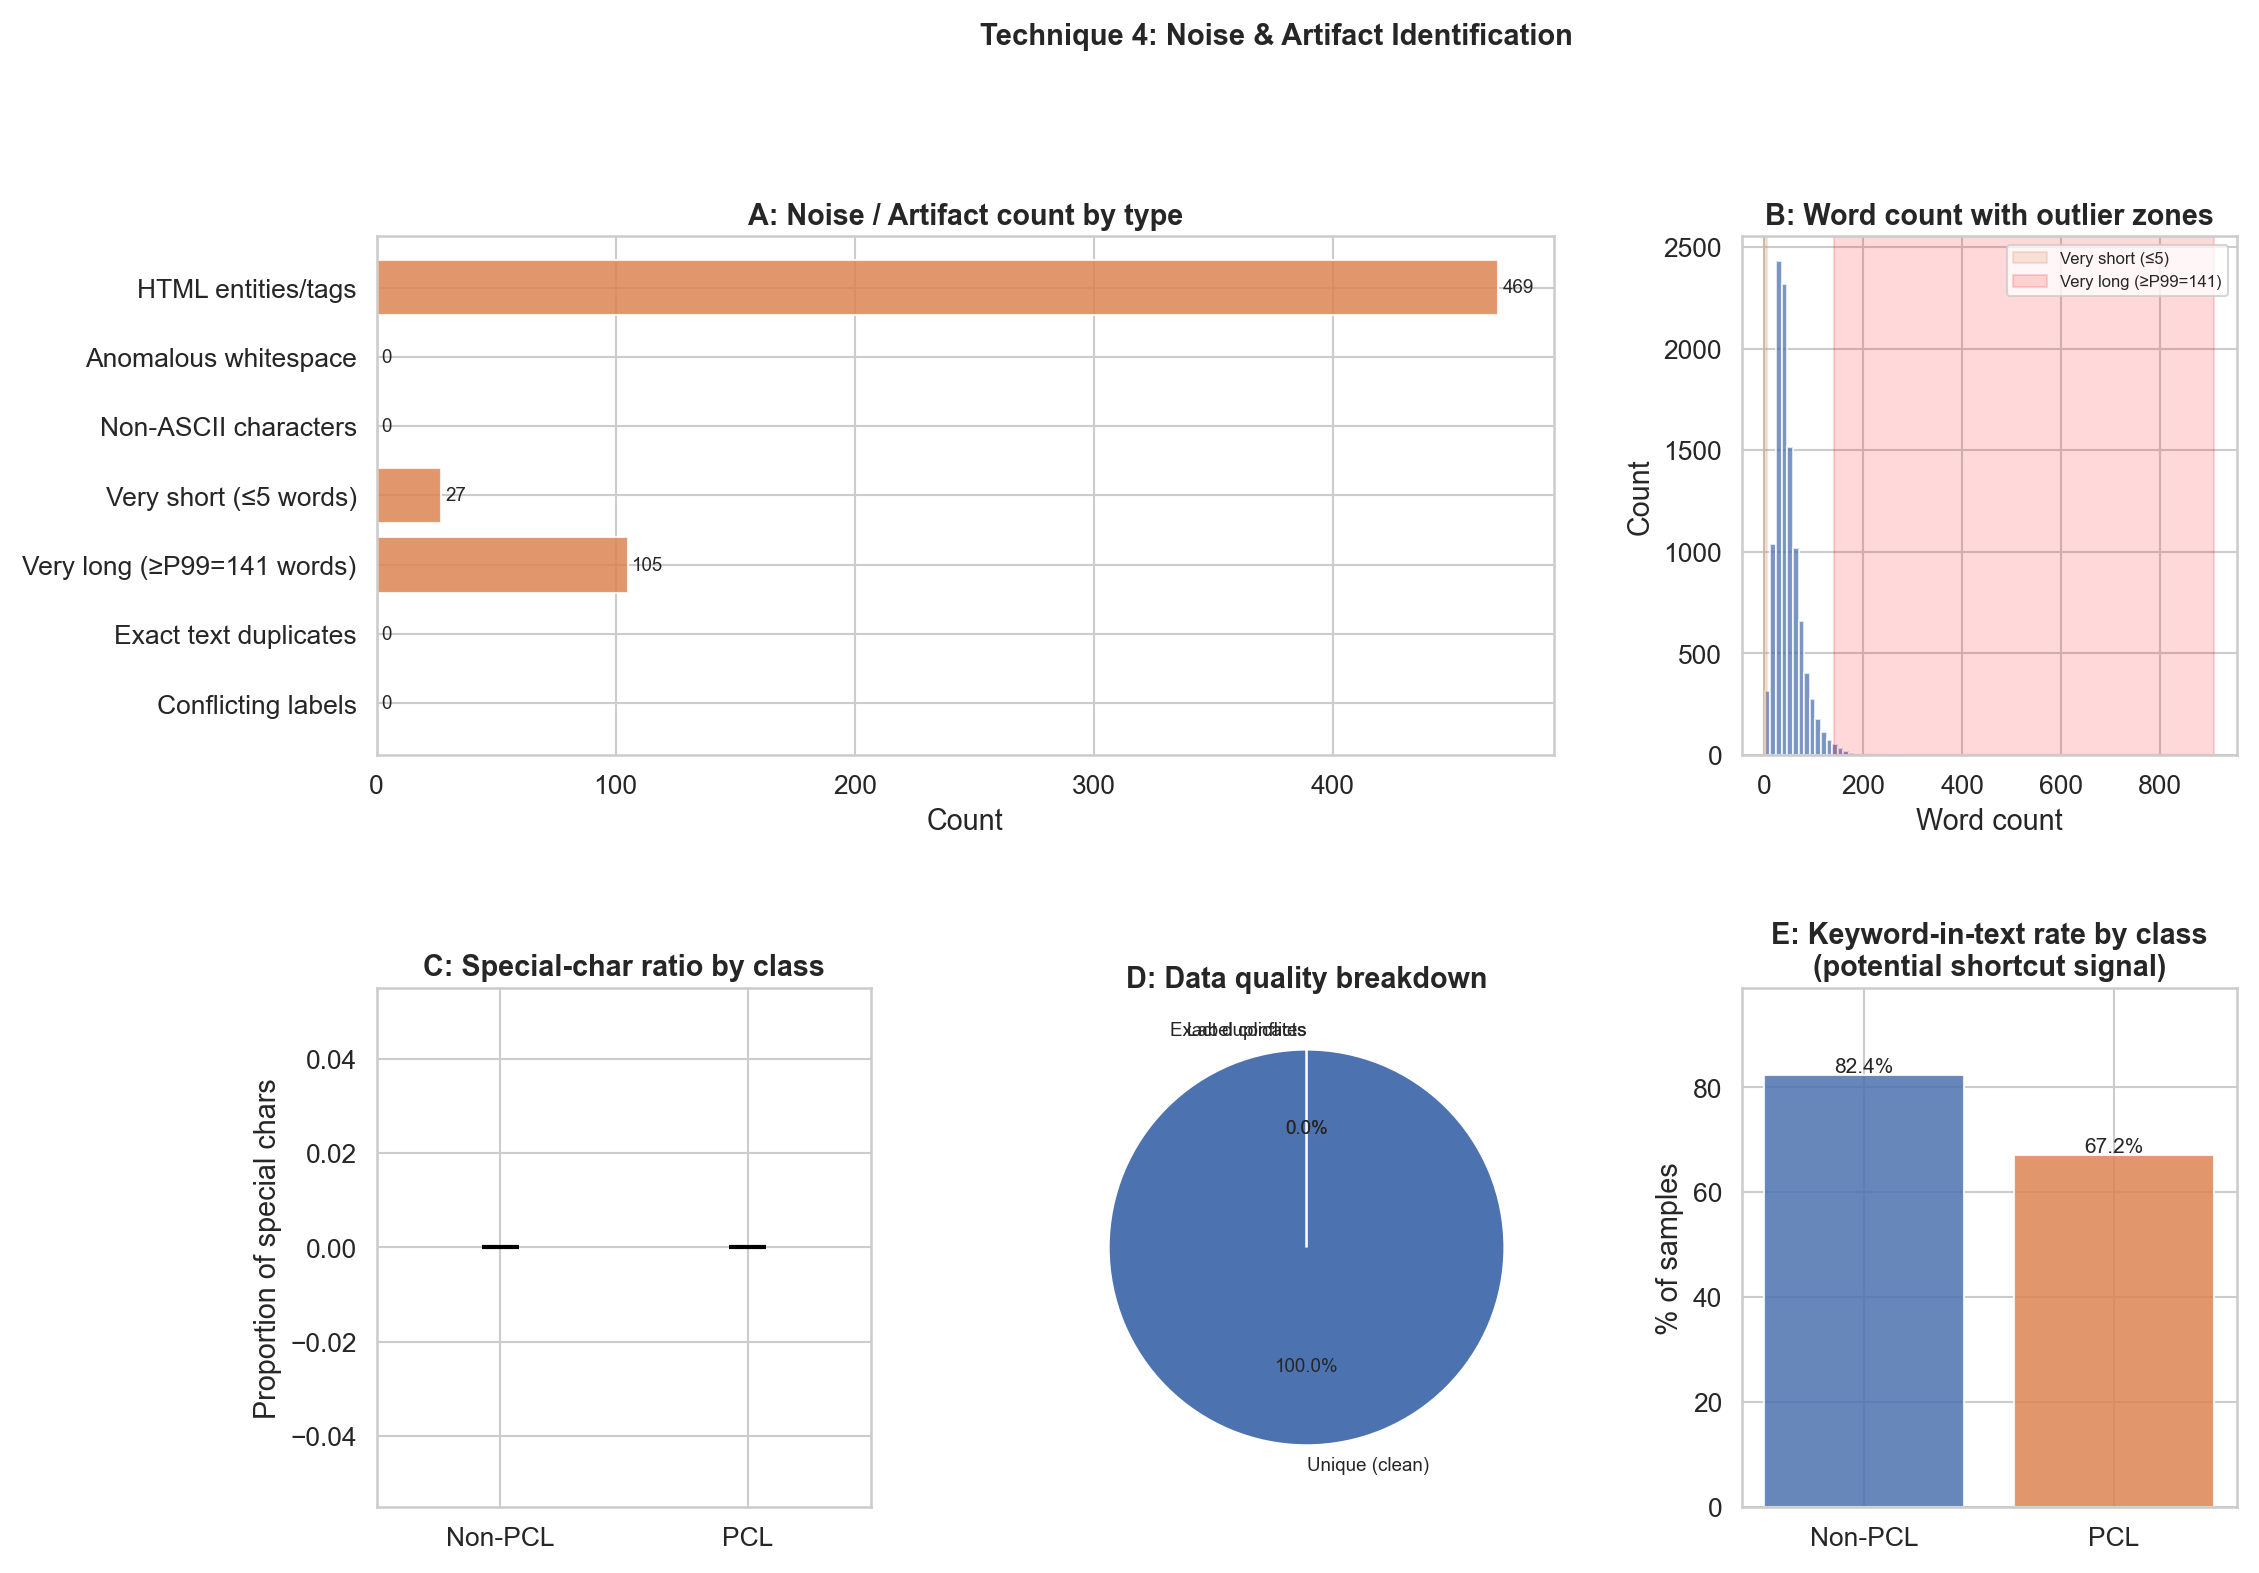

In [43]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel A: Noise type bar
ax_a = fig.add_subplot(gs[0, :2])
labels_noise = noise_summary["Issue"].tolist()
counts_noise = noise_summary["Count"].tolist()
colors_n     = [ORANGE if c > 0 else "lightgrey" for c in counts_noise]
bars = ax_a.barh(labels_noise, counts_noise, color=colors_n, alpha=0.85, edgecolor="white")
ax_a.set_title("A: Noise / Artifact count by type", fontweight="bold")
ax_a.set_xlabel("Count")
for bar, cnt in zip(bars, counts_noise):
    ax_a.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
              f"{int(cnt):,}", va="center", fontsize=9)
ax_a.invert_yaxis()

# Panel B: Word count with outlier zones
ax_b = fig.add_subplot(gs[0, 2])
ax_b.hist(df["word_count"], bins=80, color=BLUE, alpha=0.75, edgecolor="white")
ax_b.axvspan(0, 5, color=ORANGE, alpha=0.2, label="Very short (≤5)")
ax_b.axvspan(p99, df["word_count"].max(), color="red", alpha=0.15,
             label=f"Very long (≥P99={p99:.0f})")
ax_b.set_title("B: Word count with outlier zones", fontweight="bold")
ax_b.set_xlabel("Word count")
ax_b.set_ylabel("Count")
ax_b.legend(fontsize=8)

# Panel C: Special-char ratio by class
ax_c = fig.add_subplot(gs[1, 0])
data = [df.loc[df["pcl"] == 0, "special_char_ratio"].values,
        df.loc[df["pcl"] == 1, "special_char_ratio"].values]
bp = ax_c.boxplot(data, labels=["Non-PCL", "PCL"], patch_artist=True,
                  medianprops=dict(color="black", linewidth=2), showfliers=False)
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax_c.set_title("C: Special-char ratio by class", fontweight="bold")
ax_c.set_ylabel("Proportion of special chars")

# Panel D: Data quality pie
ax_d = fig.add_subplot(gs[1, 1])
clean_n  = len(df) - exact_dup_cnt - n_conflicts
vals     = [max(clean_n, 0), exact_dup_cnt, n_conflicts]
labels_d = ["Unique (clean)", "Exact duplicates", "Label conflicts"]
colors_d = [BLUE, ORANGE, "firebrick"]
ax_d.pie(vals, labels=labels_d, colors=colors_d,
         autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9})
ax_d.set_title("D: Data quality breakdown", fontweight="bold")

# Panel E: Keyword-in-text rate
ax_e = fig.add_subplot(gs[1, 2])
kit_by_class = df.groupby("pcl")["keyword_in_text"].mean() * 100
bars = ax_e.bar(["Non-PCL", "PCL"], kit_by_class.values,
                color=[BLUE, ORANGE], alpha=0.85, edgecolor="white")
ax_e.set_title("E: Keyword-in-text rate by class\n(potential shortcut signal)",
               fontweight="bold")
ax_e.set_ylabel("% of samples")
for bar, v in zip(bars, kit_by_class.values):
    ax_e.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
ax_e.set_ylim(0, max(kit_by_class.values) * 1.2)

fig.suptitle("Technique 4: Noise & Artifact Identification",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

**Analysis:** The most impactful findings are label conflicts (same text, different binary label), which arise from annotator disagreement and set a natural ceiling on achievable F1. Exact duplicates risk data leakage if they span the train/dev split. The keyword-in-text rate difference between classes, if present, indicates that topic alone may serve as a spurious shortcut signal for a naive model.

**Impact:** Label conflicts motivate inspecting the decision threshold rather than assuming 0.5 is optimal. Deduplication must happen *before* train/dev splitting to avoid inflating dev-set performance. The keyword leakage finding directly motivates a keyword-stratified error analysis in Exercise 5.2.

---
## EDA Summary

| Technique | Key Finding | Impact on Training |
|-----------|-------------|--------------------|
| 1. Statistical Profiling | ~X:1 class imbalance; >99% samples ≤256 tokens for both tokenizers | Use class-weighted loss; set `max_length=256` |
| 2. Lexical Analysis | Discriminative bigrams exist but stop-word density differs little | Surface features insufficient alone; transformer needed |
| 3. Semantic & Syntactic | Heavy class overlap in t-SNE; POS differences in modal/adj usage | Contextual embeddings essential; POS signal informs error analysis |
| 4. Noise & Artifacts | Label conflicts set F1 ceiling; keyword-in-text is potential shortcut | Dedup before split; inspect threshold; keyword-stratified error analysis |